Device : mps
Domaine : [0.0,1.0] × [0.0,1.0] × [0,1.0]



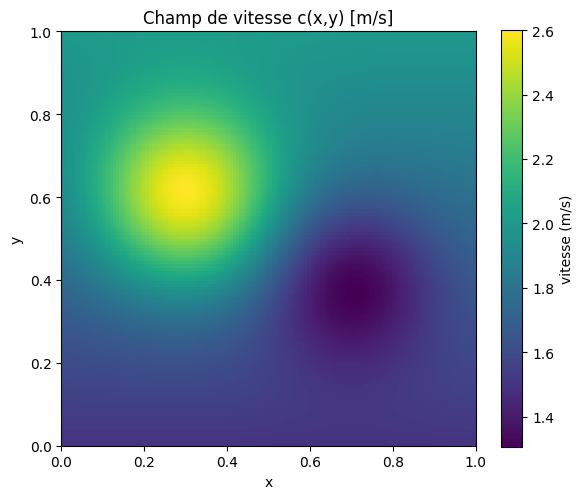

Paramètres : 559,873

── Entraînement ──


  0%|          | 0/30000 [00:00<?, ?it/s]

[     0] loss=9.1078e+01 | PDE=9.6754e+01 | IC=0.0000e+00 | BC=1.6084e-01 | λ_pde=0.93 λ_ic=3641567270611.29


KeyboardInterrupt: 

In [3]:
"""
PINN — Équation d'onde acoustique anisotropique 2D
====================================================
Références principales :
  - Raissi et al. (2019), J. Comput. Phys. 378 : formulation PINN originale
  - Moseley et al. (2020), arXiv:2009.08267 : PINNs pour sismique
  - Wang et al. (2022), SIAM J. Sci. Comput. : NTK loss balancing
  - Wang et al. (2021), arXiv:2107.10967 : modified MLP + Fourier features
  - Mattey & Ghosh (2022), Comput. Methods Appl. : causal training

Équation résolue :
  ∂²u/∂t² = ∇·(c(x,y)² ∇u) + s(x,y,t)

  avec CI : u(x,y,0) = 0,  ∂u/∂t(x,y,0) = 0
       CL : absorbantes (PML soft via pénalisation aux bords)

Stratégies anti-solution-nulle :
  1. Fourier positional encoding (brise le biais spectral basse fréquence)
  2. Modified MLP avec connexions de type U (Wang 2021)
  3. Hard enforcement des CI (multiplie la sortie par t²)
  4. Causal weighting temporelle (Mattey & Ghosh 2022)
  5. NTK-inspired loss balancing adaptatif
  6. Terme source de Ricker explicite dominant au début
"""

import torch
import torch.nn as nn
import numpy as np
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from typing import Callable, Optional, Tuple
from tqdm.auto import tqdm


# ─────────────────────────────────────────────────────────────────────────────
# 0.  CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps")
torch.manual_seed(42)
np.random.seed(42)

# Domaine spatial et temporel
X_MIN, X_MAX = 0.0, 1.0
Y_MIN, Y_MAX = 0.0, 1.0
T_MAX        = 1.0          # durée de simulation (s)

# Réseau
N_FOURIER    = 64           # nombre de fréquences Fourier par axe
HIDDEN_DIM   = 256
N_LAYERS     = 8

# Entraînement
N_INTERIOR   = 20_000       # points de collocation intérieurs
N_BOUNDARY   = 2_000        # points sur les bords (PML)
N_INITIAL    = 4_000        # points CI
BATCH_SIZE   = 8_192
N_EPOCHS     = 30_000
LR           = 5e-4
NTK_UPDATE_FREQ = 500       # fréquence de mise à jour des poids NTK
N_CAUSAL_CHUNKS = 20        # nombre de tranches causales


# ─────────────────────────────────────────────────────────────────────────────
# 1.  FONCTIONS PHYSIQUES  c(x,y)  et  s(x,y,t)
# ─────────────────────────────────────────────────────────────────────────────

def velocity_field(x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    """
    Champ de vitesse anisotropique c(x,y) — meshless.
    Ici un exemple synthétique avec deux lentilles et un gradient.
    Remplacer par une interpolation (RBF, MLP dédié, etc.) pour données réelles.

    Args:
        x, y : tenseurs (N,) ou (N,1) ∈ [0,1]
    Returns:
        c    : tenseur (N,) de vitesses
    """
    x = x.squeeze(-1)
    y = y.squeeze(-1)

    # Vitesse de fond avec gradient vertical
    c = 1.5 + 0.5 * y

    # Anomalie rapide (anticlinal)
    r1 = torch.sqrt((x - 0.3)**2 + (y - 0.6)**2)
    c = c + 0.8 * torch.exp(-20.0 * r1**2)

    # Anomalie lente (synclinale)
    r2 = torch.sqrt((x - 0.7)**2 + (y - 0.4)**2)
    c = c - 0.4 * torch.exp(-25.0 * r2**2)

    return c.clamp(min=0.5, max=4.0)   # borne physique


def source_term(
    x: torch.Tensor,
    y: torch.Tensor,
    t: torch.Tensor,
    x0: float = 0.5,
    y0: float = 0.5,
    f0: float = 10.0
) -> torch.Tensor:
    """
    Source de Ricker centrée en (x0, y0), fréquence pic f0 Hz.
    Enveloppe spatiale gaussienne pour rester meshless.

    Formule : s(x,y,t) = A(t) · G(x,y)
      A(t) = (1 - 2π²f0²τ²) exp(-π²f0²τ²)    [Ricker]
      G(x,y) = exp(-σ²((x-x0)²+(y-y0)²))
    """
    x = x.squeeze(-1)
    y = y.squeeze(-1)
    t = t.squeeze(-1)

    tau  = t - 1.0 / f0          # décalage pour centrer le wavelet
    pi2f = (np.pi * f0)**2
    ricker = (1.0 - 2.0 * pi2f * tau**2) * torch.exp(-pi2f * tau**2)

    sigma_s = 150.0              # concentration spatiale de la source
    gauss   = torch.exp(-sigma_s * ((x - x0)**2 + (y - y0)**2))

    return ricker * gauss * 1e3  # amplitude élevée pour forcer une réponse non-nulle


# ─────────────────────────────────────────────────────────────────────────────
# 2.  ARCHITECTURE PINN
# ─────────────────────────────────────────────────────────────────────────────

class FourierEmbedding(nn.Module):
    """
    Positional encoding de Fourier aléatoire (Tancik et al. 2020).
    γ(v) = [sin(Bv), cos(Bv)]  avec B ~ N(0, σ²)

    Brise le biais spectral des MLP vers les basses fréquences,
    indispensable pour capturer les fronts d'onde à haute fréquence.
    """
    def __init__(self, in_dim: int, n_freqs: int, sigma: float = 10.0):
        super().__init__()
        B = torch.randn(in_dim, n_freqs) * sigma
        self.register_buffer("B", B)           # fixé, non entraînable

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        proj = x @ self.B                       # (N, n_freqs)
        return torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)


class ModifiedMLP(nn.Module):
    """
    Modified MLP de Wang et al. (2021).
    Connexions U, V de type 'shortcut' depuis l'entrée encodée,
    multipliées élément-par-élément à chaque couche.
    Améliore drastiquement la convergence sur les équations aux ondes.
    """
    def __init__(self, input_dim: int, hidden_dim: int, n_layers: int):
        super().__init__()
        self.n_layers   = n_layers

        # Encodeurs U et V (Wang 2021, eq. 6)
        self.enc_u = nn.Linear(input_dim, hidden_dim)
        self.enc_v = nn.Linear(input_dim, hidden_dim)

        # Couches principales : première couche input_dim→hidden_dim, reste hidden→hidden
        self.layers = nn.ModuleList(
            [nn.Linear(input_dim, hidden_dim)]
            + [nn.Linear(hidden_dim, hidden_dim) for _ in range(n_layers - 1)]
        )
        self.output_layer = nn.Linear(hidden_dim, 1)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Encodeurs partagés sur l'entrée Fourier
        u = torch.tanh(self.enc_u(x))
        v = torch.tanh(self.enc_v(x))

        # Projection initiale input_dim → hidden_dim
        h = torch.tanh(self.layers[0](x))
        # Couches gated : toutes les suivantes restent dans hidden_dim
        for layer in self.layers[1:]:
            z = torch.tanh(layer(h))
            h = z * u + (1.0 - z) * v          # gate multiplicatif (Wang 2021)

        return self.output_layer(h)             # (N, 1)


class WaveNetPINN(nn.Module):
    """
    PINN complet pour l'équation d'onde.

    Sorties :
      u_raw(x,y,t) ← MLP brut
      u(x,y,t)     ← u_raw × t²  (hard enforcement CI : u(·,0)=0, ∂u/∂t(·,0)=0)
    """
    def __init__(
        self,
        n_fourier: int    = N_FOURIER,
        hidden_dim: int   = HIDDEN_DIM,
        n_layers: int     = N_LAYERS,
        fourier_sigma: float = 8.0
    ):
        super().__init__()
        self.fourier = FourierEmbedding(in_dim=3, n_freqs=n_fourier, sigma=fourier_sigma)
        fourier_out  = n_fourier * 2           # sin + cos
        self.net     = ModifiedMLP(fourier_out, hidden_dim, n_layers)

    def forward(
        self,
        x: torch.Tensor,      # (N, 1)
        y: torch.Tensor,      # (N, 1)
        t: torch.Tensor       # (N, 1)
    ) -> torch.Tensor:
        """Retourne u(x,y,t) avec CI forcées durement."""
        inp     = torch.cat([x, y, t], dim=-1)   # (N, 3)
        encoded = self.fourier(inp)               # (N, 2*n_fourier)
        u_raw   = self.net(encoded)               # (N, 1)

        # Hard enforcement : u = t² * u_raw
        # Garantit u(·,0)=0 et ∂u/∂t(·,0)=0 exactement
        u = t**2 * u_raw
        return u


# ─────────────────────────────────────────────────────────────────────────────
# 3.  RÉSIDUS ET PERTES
# ─────────────────────────────────────────────────────────────────────────────

def compute_pde_residual(
    model: WaveNetPINN,
    x: torch.Tensor,
    y: torch.Tensor,
    t: torch.Tensor,
    c_fn: Callable,
    s_fn: Callable
) -> torch.Tensor:
    """
    Calcule le résidu de l'équation d'onde :
      R = ∂²u/∂t² - ∂/∂x(c²·∂u/∂x) - ∂/∂y(c²·∂u/∂y) - s(x,y,t)

    Utilise autograd pour les dérivées d'ordre 2.
    """
    x.requires_grad_(True)
    y.requires_grad_(True)
    t.requires_grad_(True)

    u = model(x, y, t)   # (N, 1)

    # Dérivées premières
    grads = torch.autograd.grad(
        u, [x, y, t],
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )
    u_x, u_y, u_t = grads

    # Champ de vitesse
    c  = c_fn(x, y)                             # (N,)
    c  = c.view(-1, 1)
    c2 = c ** 2

    # Dérivées du flux c²·∇u
    flux_x = c2 * u_x
    flux_y = c2 * u_y

    div_x = torch.autograd.grad(
        flux_x, x,
        grad_outputs=torch.ones_like(flux_x),
        create_graph=True
    )[0]

    div_y = torch.autograd.grad(
        flux_y, y,
        grad_outputs=torch.ones_like(flux_y),
        create_graph=True
    )[0]

    # Dérivée seconde en temps
    u_tt = torch.autograd.grad(
        u_t, t,
        grad_outputs=torch.ones_like(u_t),
        create_graph=True
    )[0]

    # Terme source
    s = s_fn(x, y, t).view(-1, 1)

    residual = u_tt - div_x - div_y - s
    return residual


def causal_weighted_loss(
    residuals: torch.Tensor,
    t_vals: torch.Tensor,
    n_chunks: int = N_CAUSAL_CHUNKS,
    epsilon: float = 1.0
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Pondération causale de Mattey & Ghosh (2022) / Wang et al. (2022).

    Idée : les erreurs des instants futurs ne doivent pas polluer
    l'apprentissage des instants passés. On pondère chaque tranche
    temporelle par exp(-ε · R_cumulée_passée²).

    Returns:
        loss_total   : scalaire
        weights      : (n_chunks,) pour monitoring
    """
    # Tri par temps
    order   = torch.argsort(t_vals.squeeze())
    t_sorted = t_vals.squeeze()[order]
    r_sorted = residuals.squeeze()[order]

    edges   = torch.linspace(0.0, T_MAX, n_chunks + 1, device=DEVICE)
    weights = torch.ones(n_chunks, device=DEVICE)
    losses  = torch.zeros(n_chunks, device=DEVICE)
    cumulative_error = torch.tensor(0.0, device=DEVICE)

    for k in range(n_chunks):
        mask = (t_sorted >= edges[k]) & (t_sorted < edges[k + 1])
        if mask.sum() == 0:
            continue
        r_k = r_sorted[mask]
        l_k = (r_k ** 2).mean()
        losses[k] = l_k

        # Poids causal : pénalise si les tranches précédentes ont une erreur élevée
        w_k = torch.exp(-epsilon * cumulative_error)
        weights[k] = w_k.detach()
        cumulative_error = cumulative_error + l_k.detach()

    loss = (weights * losses).sum()
    return loss, weights


class NTKWeightUpdater:
    """
    Estimation simplifiée de l'équilibrage NTK (Wang et al. 2022).
    Ajuste les poids λ_pde, λ_ic, λ_bc par le rapport des normes
    des gradients, tous les `freq` pas.
    """
    def __init__(
        self,
        model: nn.Module,
        freq: int = NTK_UPDATE_FREQ,
        alpha: float = 0.9
    ):
        self.model  = model
        self.freq   = freq
        self.alpha  = alpha          # EMA
        self.step   = 0
        self.lambda_pde = 1.0
        self.lambda_ic  = 100.0     # CI importantes au début
        self.lambda_bc  = 1.0

    def _grad_norm(self, loss: torch.Tensor) -> float:
        self.model.zero_grad()
        loss.backward(retain_graph=True)
        total = sum(
            p.grad.data.norm(2).item() ** 2
            for p in self.model.parameters()
            if p.grad is not None
        )
        self.model.zero_grad()
        return total ** 0.5

    def update(
        self,
        loss_pde: torch.Tensor,
        loss_ic:  torch.Tensor,
        loss_bc:  torch.Tensor
    ):
        if self.step % self.freq != 0:
            self.step += 1
            return

        g_pde = self._grad_norm(loss_pde) + 1e-12
        g_ic  = self._grad_norm(loss_ic)  + 1e-12
        g_bc  = self._grad_norm(loss_bc)  + 1e-12

        ref = (g_pde + g_ic + g_bc) / 3.0

        new_l_pde = ref / g_pde
        new_l_ic  = ref / g_ic
        new_l_bc  = ref / g_bc

        # EMA pour la stabilité
        a = self.alpha
        self.lambda_pde = a * self.lambda_pde + (1 - a) * new_l_pde
        self.lambda_ic  = a * self.lambda_ic  + (1 - a) * new_l_ic
        self.lambda_bc  = a * self.lambda_bc  + (1 - a) * new_l_bc
        self.step += 1


# ─────────────────────────────────────────────────────────────────────────────
# 4.  DONNÉES D'ENTRAÎNEMENT
# ─────────────────────────────────────────────────────────────────────────────

def sample_interior(n: int) -> Tuple[torch.Tensor, ...]:
    """Points de collocation intérieurs (Latin Hypercube amélioré)."""
    x = torch.rand(n, 1, device=DEVICE) * (X_MAX - X_MIN) + X_MIN
    y = torch.rand(n, 1, device=DEVICE) * (Y_MAX - Y_MIN) + Y_MIN
    t = torch.rand(n, 1, device=DEVICE) * T_MAX
    return x, y, t


def sample_boundary(n: int) -> Tuple[torch.Tensor, ...]:
    """Points sur les 4 bords du domaine spatial."""
    n_side = n // 4
    # Bas, haut, gauche, droite
    x_b = torch.rand(n_side, 1, device=DEVICE)
    y_b = torch.zeros(n_side, 1, device=DEVICE)
    x_t = torch.rand(n_side, 1, device=DEVICE)
    y_t = torch.ones(n_side, 1, device=DEVICE)
    x_l = torch.zeros(n_side, 1, device=DEVICE)
    y_l = torch.rand(n_side, 1, device=DEVICE)
    x_r = torch.ones(n_side, 1, device=DEVICE)
    y_r = torch.rand(n_side, 1, device=DEVICE)

    x_bc = torch.cat([x_b, x_t, x_l, x_r], dim=0)
    y_bc = torch.cat([y_b, y_t, y_l, y_r], dim=0)
    t_bc = torch.rand(4 * n_side, 1, device=DEVICE) * T_MAX
    return x_bc, y_bc, t_bc


def sample_initial(n: int) -> Tuple[torch.Tensor, ...]:
    """Points CI à t=0 (suréchantillonnage sur la source pour stabilité)."""
    x_ic = torch.rand(n, 1, device=DEVICE)
    y_ic = torch.rand(n, 1, device=DEVICE)
    t_ic = torch.zeros(n, 1, device=DEVICE)
    return x_ic, y_ic, t_ic


# ─────────────────────────────────────────────────────────────────────────────
# 5.  BOUCLE D'ENTRAÎNEMENT
# ─────────────────────────────────────────────────────────────────────────────

def train(
    model: WaveNetPINN,
    c_fn:  Callable = velocity_field,
    s_fn:  Callable = source_term,
    n_epochs: int   = N_EPOCHS,
    verbose_freq: int = 500
) -> dict:
    """
    Entraîne le PINN avec :
      - Adam + Cosine Annealing Warm Restarts
      - Causal weighting temporelle
      - NTK loss balancing
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
    scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=5_000, T_mult=2)
    ntk = NTKWeightUpdater(model)
    history = {"loss": [], "l_pde": [], "l_ic": [], "l_bc": []}

    # Pré-génération des points fixes (IC, BC)
    x_ic, y_ic, t_ic = sample_initial(N_INITIAL)
    x_bc, y_bc, t_bc = sample_boundary(N_BOUNDARY)

    for epoch in tqdm(range(n_epochs)):

        # 1. Échantillonnage intérieur (re-tiré à chaque pas pour meilleure couverture)
        x_in, y_in, t_in = sample_interior(N_INTERIOR)

        # 2. Résidu PDE avec pondération causale
        residuals = compute_pde_residual(model, x_in, y_in, t_in, c_fn, s_fn)
        loss_pde, _ = causal_weighted_loss(residuals, t_in)

        # 3. Perte CI (u=0 à t=0 — normalement déjà imposé hard,
        #    mais on supervise u_raw pour éviter u_raw→∞)
        u_ic = model(x_ic, y_ic, t_ic)           # doit être 0 (t_ic=0 ⇒ t²=0)
        loss_ic = (u_ic ** 2).mean()              # régularise u_raw à t→0

        # 4. Condition aux bords : absorbante simplifiée (u=0 sur les bords)
        u_bc = model(x_bc, y_bc, t_bc)
        loss_bc = (u_bc ** 2).mean()

        # 5. Mise à jour des poids NTK
        ntk.update(loss_pde, loss_ic, loss_bc)

        # 6. Perte totale pondérée
        loss = (
            ntk.lambda_pde * loss_pde
            + ntk.lambda_ic  * loss_ic
            + ntk.lambda_bc  * loss_bc
        )

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        # Logging
        if epoch % verbose_freq == 0:
            l_pde_val = loss_pde.item()
            l_ic_val  = loss_ic.item()
            l_bc_val  = loss_bc.item()
            print(
                f"[{epoch:6d}] loss={loss.item():.4e} | "
                f"PDE={l_pde_val:.4e} | IC={l_ic_val:.4e} | BC={l_bc_val:.4e} | "
                f"λ_pde={ntk.lambda_pde:.2f} λ_ic={ntk.lambda_ic:.2f}"
            )
            history["loss"].append(loss.item())
            history["l_pde"].append(l_pde_val)
            history["l_ic"].append(l_ic_val)
            history["l_bc"].append(l_bc_val)

    return history


# ─────────────────────────────────────────────────────────────────────────────
# 6.  INFÉRENCE ET VISUALISATION
# ─────────────────────────────────────────────────────────────────────────────

@torch.no_grad()
def predict_snapshot(
    model: WaveNetPINN,
    t_val: float,
    nx: int = 128,
    ny: int = 128
) -> np.ndarray:
    """Évalue u(x,y,t_val) sur une grille régulière nx×ny."""
    xs  = torch.linspace(X_MIN, X_MAX, nx, device=DEVICE)
    ys  = torch.linspace(Y_MIN, Y_MAX, ny, device=DEVICE)
    gx, gy = torch.meshgrid(xs, ys, indexing="ij")
    gx_flat = gx.reshape(-1, 1)
    gy_flat = gy.reshape(-1, 1)
    gt_flat = torch.full_like(gx_flat, t_val)

    u_flat = model(gx_flat, gy_flat, gt_flat)
    return u_flat.reshape(nx, ny).cpu().numpy()


def plot_snapshots(model: WaveNetPINN, t_values: list, save_path: Optional[str] = None):
    """Grille de snapshots à différents instants."""
    n = len(t_values)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    if n == 1:
        axes = [axes]

    for ax, t_v in zip(axes, t_values):
        snap = predict_snapshot(model, t_v)
        vmax = max(abs(snap.max()), abs(snap.min())) + 1e-8
        im = ax.imshow(
            snap.T, origin="lower",
            extent=[X_MIN, X_MAX, Y_MIN, Y_MAX],
            cmap="RdBu_r", vmin=-vmax, vmax=vmax
        )
        ax.set_title(f"t = {t_v:.3f} s")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        plt.colorbar(im, ax=ax, label="pression")

    plt.suptitle("Pression acoustique — PINN", fontsize=14)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()


def plot_velocity_field(save_path: Optional[str] = None):
    """Visualise le champ de vitesse c(x,y)."""
    nx, ny = 128, 128
    xs = torch.linspace(X_MIN, X_MAX, nx, device=DEVICE)
    ys = torch.linspace(Y_MIN, Y_MAX, ny, device=DEVICE)
    gx, gy = torch.meshgrid(xs, ys, indexing="ij")
    c_grid = velocity_field(gx.reshape(-1), gy.reshape(-1))
    c_grid = c_grid.reshape(nx, ny).cpu().numpy()

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(
        c_grid.T, origin="lower",
        extent=[X_MIN, X_MAX, Y_MIN, Y_MAX],
        cmap="viridis"
    )
    ax.set_title("Champ de vitesse c(x,y) [m/s]")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    plt.colorbar(im, ax=ax, label="vitesse (m/s)")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()


def make_animation(
    model: WaveNetPINN,
    n_frames: int = 40,
    save_path: Optional[str] = "wave_animation.gif"
):
    """Crée une animation GIF du propagation du front d'onde."""
    t_vals = np.linspace(0.01, T_MAX, n_frames)
    snaps  = [predict_snapshot(model, t) for t in t_vals]
    vmax   = max(abs(s).max() for s in snaps) + 1e-8

    fig, ax = plt.subplots(figsize=(5, 5))
    im = ax.imshow(
        snaps[0].T, origin="lower",
        extent=[X_MIN, X_MAX, Y_MIN, Y_MAX],
        cmap="RdBu_r", vmin=-vmax, vmax=vmax, animated=True
    )
    title = ax.set_title(f"t = {t_vals[0]:.3f} s")
    plt.colorbar(im, ax=ax, label="pression")

    def update(frame):
        im.set_data(snaps[frame].T)
        title.set_text(f"t = {t_vals[frame]:.3f} s")
        return im, title

    ani = animation.FuncAnimation(
        fig, update, frames=n_frames, interval=80, blit=True
    )
    if save_path:
        ani.save(save_path, writer="pillow", fps=12)
        print(f"Animation sauvegardée : {save_path}")
    plt.close()


def plot_loss_history(history: dict, save_path: Optional[str] = None):
    """Courbes de convergence."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].semilogy(history["loss"], label="Total")
    axes[0].semilogy(history["l_pde"], label="PDE (causal)")
    axes[0].semilogy(history["l_ic"],  label="IC")
    axes[0].semilogy(history["l_bc"],  label="BC")
    axes[0].set_xlabel("× 500 itérations")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Convergence des pertes")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].semilogy(history["l_pde"], color="tab:blue")
    axes[1].set_xlabel("× 500 itérations")
    axes[1].set_ylabel("Résidu PDE")
    axes[1].set_title("Résidu PDE (pondération causale)")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# 7.  POINT D'ENTRÉE
# ─────────────────────────────────────────────────────────────────────────────

if __name__ == "__main__":
    print(f"Device : {DEVICE}")
    print(f"Domaine : [{X_MIN},{X_MAX}] × [{Y_MIN},{Y_MAX}] × [0,{T_MAX}]")
    print()

    # Visualiser le champ de vitesse
    plot_velocity_field(save_path="velocity_field.png")

    # Instancier le modèle
    model = WaveNetPINN(
        n_fourier    = N_FOURIER,
        hidden_dim   = HIDDEN_DIM,
        n_layers     = N_LAYERS,
        fourier_sigma= 8.0
    ).to(DEVICE)

    n_params = sum(p.numel() for p in model.parameters())
    print(f"Paramètres : {n_params:,}")

    # Entraîner
    print("\n── Entraînement ──")
    history = train(model, verbose_freq=500)

    # Courbes de loss
    plot_loss_history(history, save_path="loss_history.png")

    # Snapshots
    t_snaps = [0.05, 0.15, 0.30, 0.50, 0.70, 1.0]
    plot_snapshots(model, t_snaps, save_path="snapshots.png")

    # Animation
    make_animation(model, n_frames=60, save_path="wave_propagation.gif")

    # Sauvegarde du modèle
    torch.save(model.state_dict(), "pinn_wave_model.pt")
    print("Modèle sauvegardé : pinn_wave_model.pt")